# CHAPTER-20_______________________________________________Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<b>Feature engineering</b>:-_It is a the process of using domain knowledge and various data manipulation techniques to transform raw data into a set of features that can be effectively used by machine learning algorithms_

<fieldset>
    <legend>IMPORTANCE</legend>
    <p>a model with a good dataset can often outperform a more sophisticated model trained on poorly structured or noisy data</p>
    <ol>
        <li>Data Quality and Structure = <b>60-80%</b></li>
        <li>Others = <b>40-20%</b></li>
    </ol>
</fieldset>

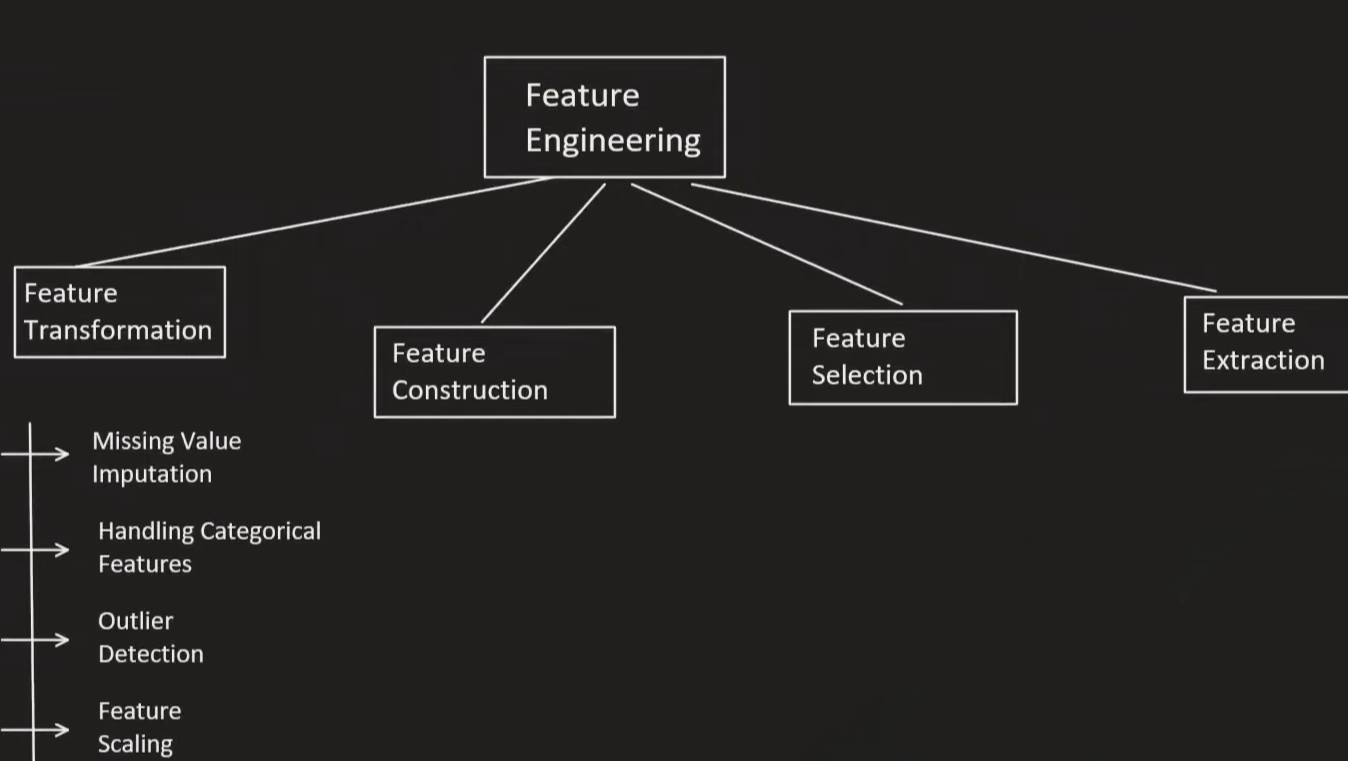

<div class="alert alert-info">                  
<center><h1><b>Feature Transformation</b></h1></center>
</div>  

<div class="alert alert-warning"><center><h2>Feature Scaling</h2></center></div>

<h3 class="alert alert-block alert-success">|:----preliminary work----:|</h3>

In [2]:
data=pd.read_csv("homeprices.csv")
print("size =",data.size)
print("shape =",data.shape)
data.head(2)

size = 36
shape = (9, 4)


,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000


In [3]:
data.isnull().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [4]:
average_value=np.round(data["bedrooms"].mean())
data.fillna(average_value,inplace=True)
data.isnull().sum()

area        0
bedrooms    0
age         0
price       0
dtype: int64

In [5]:
data.duplicated().sum()

0

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      9 non-null      int64  
 1   bedrooms  9 non-null      float64
 2   age       9 non-null      int64  
 3   price     9 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 420.0 bytes


**Feature Scaling** _is a data preprocessing technique used in machine learning to transform the numerical features of a dataset to a similar scale_.

**TYPES**  
<ol>
    <li><b>StandarDization</b><p>Transforms to mean 0, standard deviation 1</p></li>
    <li><b>Normalizition</b><p>Scales to a fixed range (e.g., 0-1)</p></li>
</ol>

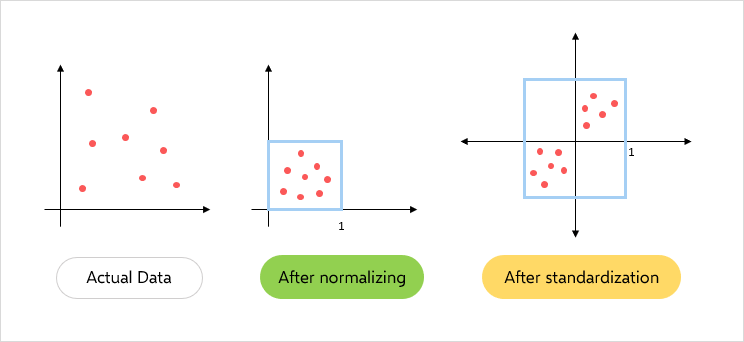

<h3 class="alert alert-block alert-success"> StandarDization</h3>

```python 
Z = (X - μ) / σ 
```
|value|            define                   |
|-----|-------------------------------------|
|  Z  | is the standardized value (Z-score).||  x  | is the original data value          |
|  μ  | is the mean of the feature          |
|  σ  | is the standard deviation of t      |

_In StandarDization the **mean(μ)** of the array is changed to **"0"** and the **standard(σ) deviation** to **'1'**_

In [7]:
x=data.iloc[:,:-1]
y=data["price"]
print(f"distance = {x.shape} \ntip = {y.shape}")

distance = (9, 3) 
tip = (9,)


In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)
print("x_train =",x_train.shape)
print("x_test =",x_test.shape)

x_train = (6, 3)
x_test = (3, 3)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the x train to learn the perameters mean and standard devition
scaler.fit(x_train)

print(f"The mean({scaler.mean_}) and the Standard devition({scaler.scale_}) of x_train is calculated")

The mean([3633.33333333    4.66666667   14.        ]) and the Standard devition([639.44420311   1.37436854   8.92561856]) of x_train is calculated


In [10]:
# transform train-test set
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

# it returns a numpy array
print(f"{type(x_train_scaled)}")
x_train_scaled[:5]

<class 'numpy.ndarray'>


array([[-0.0521286 , -1.21267813,  1.79259285],
       [ 1.04257207,  0.9701425 , -0.78425937],
       [-0.99044347, -0.48507125,  0.11203705],
       [ 0.88618626,  0.9701425 , -1.12037053],
       [ 0.72980045,  0.9701425 , -0.67222232]])

In [11]:
# converting ndarray to data frame
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

x_train_scaled.head(5)

,area,bedrooms,age
0,-0.052129,-1.212678,1.792593
1,1.042572,0.970143,-0.784259
2,-0.990443,-0.485071,0.112037
3,0.886186,0.970143,-1.120371
4,0.729800,0.970143,-0.672222


#### comparison of mean and standard deviation

In [12]:
np.round(x_train.describe())

,area,bedrooms,age
count,6.0,6.0,6.0
mean,3633.0,5.0,14.0
std,700.0,2.0,10.0
min,2600.0,3.0,4.0
25%,3150.0,3.0,7.0
50%,3850.0,5.0,12.0
75%,4175.0,6.0,19.0
max,4300.0,6.0,30.0


In [13]:
np.round(x_train_scaled.describe())

,area,bedrooms,age
count,6.0,6.0,6.0
mean,-0.0,-0.0,-0.0
std,1.0,1.0,1.0
min,-2.0,-1.0,-1.0
25%,-1.0,-1.0,-1.0
50%,0.0,0.0,-0.0
75%,1.0,1.0,1.0
max,1.0,1.0,2.0


Text(0.5, 1.0, 'After Scaling')

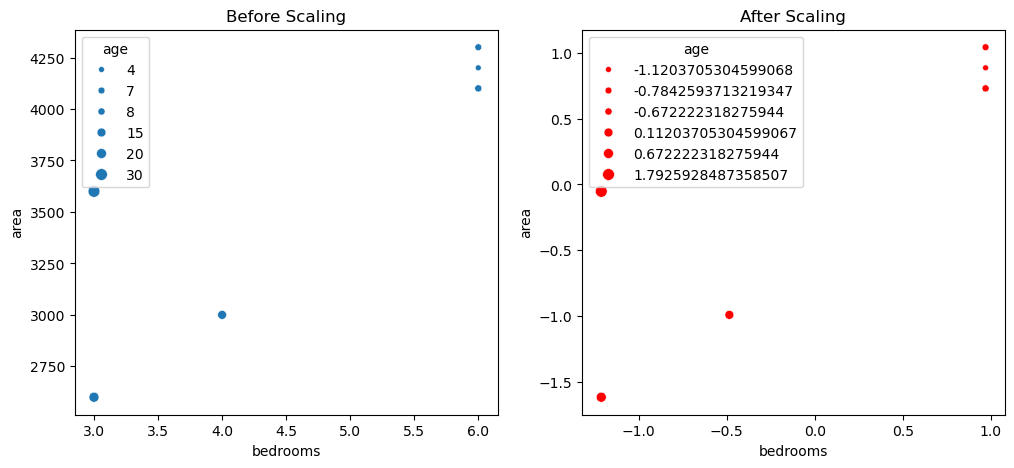

In [14]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(12,5))

sns.scatterplot(x=x_train["bedrooms"],y=x_train["area"],ax=ax[0],size=x_train["age"])
ax[0].set_title("Before Scaling")

sns.scatterplot(x=x_train_scaled["bedrooms"],y=x_train_scaled["area"],ax=ax[1],size=x_train_scaled["age"],color="red")
ax[1].set_title("After Scaling")

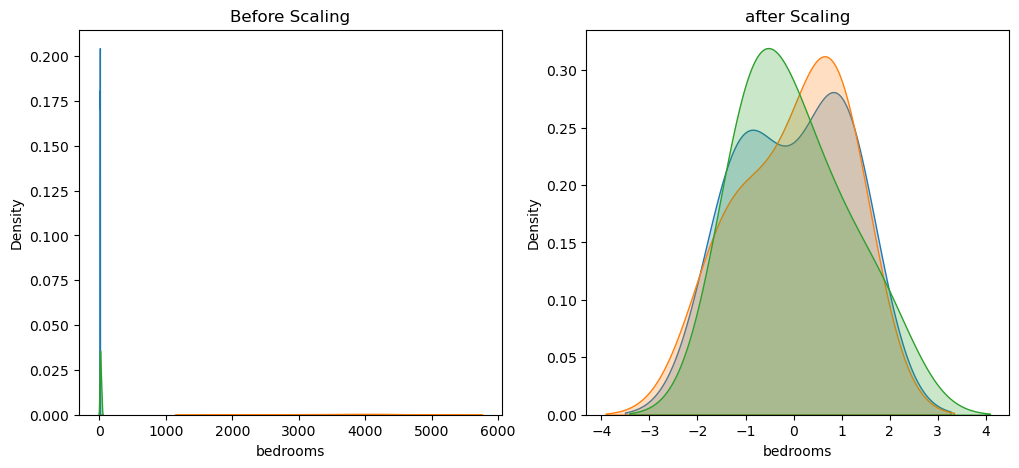

In [15]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))

ax1.set_title("Before Scaling")
sns.kdeplot(x_train["bedrooms"],fill=True,ax=ax1)
sns.kdeplot(x_train["area"],fill=True,ax=ax1)
sns.kdeplot(x_train["age"],fill=True,ax=ax1)

ax2.set_title("after Scaling")
sns.kdeplot(x_train_scaled["bedrooms"],fill=True,ax=ax2)
sns.kdeplot(x_train_scaled["area"],fill=True,ax=ax2)
sns.kdeplot(x_train_scaled["age"],fill=True,ax=ax2)
plt.show()

#### When to use StandarDization

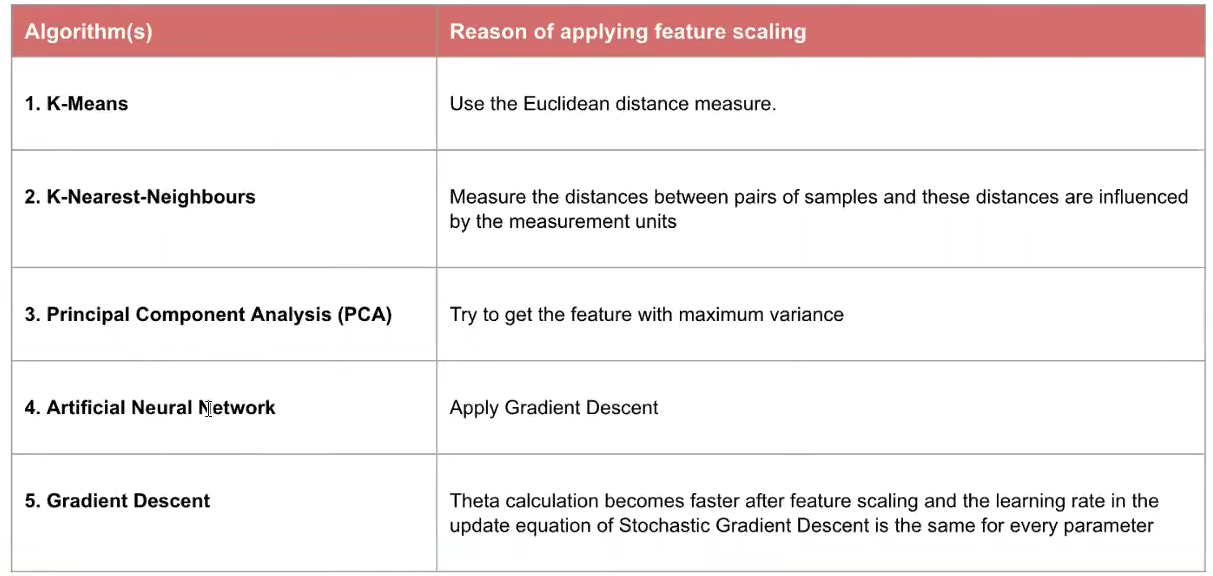

#### 6. **Regression**

<h3 class="alert alert-block alert-success"> Normalizition</h3>

#### Types
| **Types** | _When to Use_ | **Formulas** |
|-----------|---------------|--------------|
|MinMax Scaling (0 to 1)|When min and max value is known|$new X_i = \frac{X_i - Xmin}{Xmax - Xmin}$|
|Mean Normalizition (-1 to 1)| when we want centered data|$new X_ = \frac{X_i - Xmean}{Xmax - Xmin}i$|
|MaxAbsolute Scaling| when we have sparse data (many zero's)|$new X_i = \frac{X_i}{|Xmax|}$|
|Robust Scaling|When there are Outliers|$new X_i = \frac{X_i - Xmedian}{IQR}$|

In [16]:
data.head(2)

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000


In [17]:
x=data.iloc[:,[1,2]]
y=data.iloc[:,-1]

In [18]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25)
print("xtrain =",xtrain.shape)
print("xtest =",xtest.shape)

xtrain = (6, 2)
xtest = (3, 2)


In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(xtrain)
xtrain_scaled = scaler.transform(xtrain)
xtest_scaled = scaler.transform(xtest)

#### comparison

In [20]:
xtrain_scaled=pd.DataFrame(xtrain_scaled)
xtest_scaled=pd.DataFrame(xtest_scaled)

In [21]:
pd.concat([xtrain.reset_index(),xtrain_scaled],axis=1)

,index,bedrooms,age,0,1
0,1,4.0,15,0.333333,0.423077
1,0,3.0,20,0.000000,0.615385
2,3,3.0,30,0.000000,1.000000
3,2,5.0,18,0.666667,0.538462
4,5,6.0,8,1.000000,0.153846
5,8,6.0,4,1.000000,0.000000


<Axes: xlabel='0', ylabel='1'>

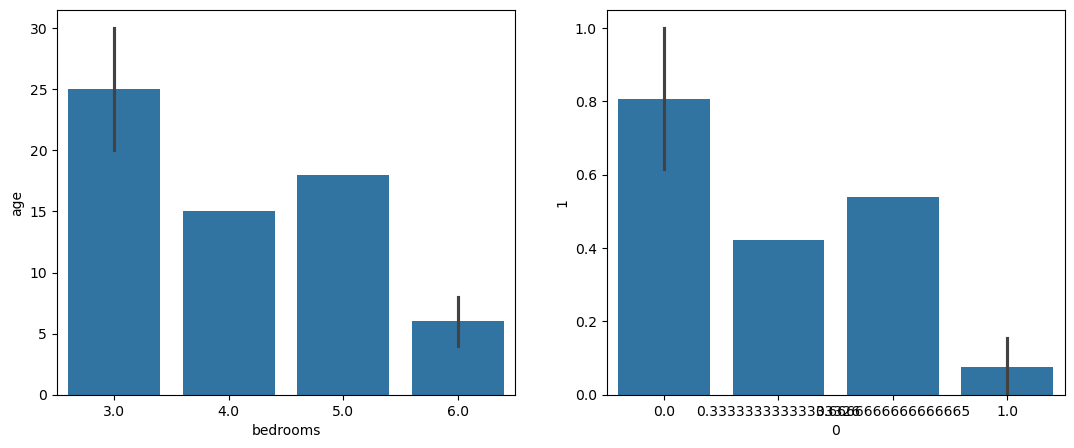

In [22]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(13,5))
sns.barplot(x=xtrain["bedrooms"],y=xtrain["age"],ax=ax[0])
sns.barplot(x=xtrain_scaled[0],y=xtrain_scaled[1],ax=ax[1])

Text(0.5, 1.0, 'after Scaling')

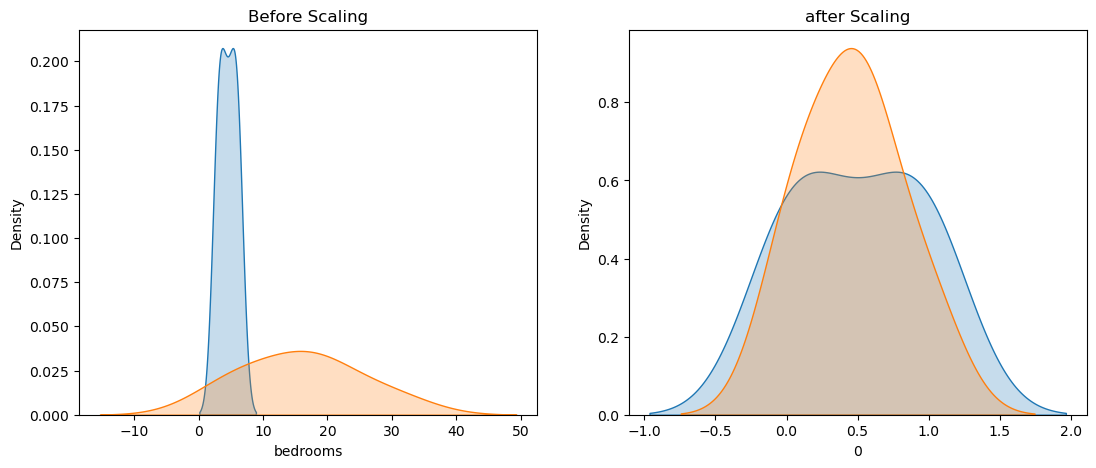

In [23]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(13,5))
sns.kdeplot(xtrain["bedrooms"],fill=True,ax=ax[0])
sns.kdeplot(xtrain["age"],fill=True,ax=ax[0])
ax[0].set_title("Before Scaling")

sns.kdeplot(xtrain_scaled[0],fill=True,ax=ax[1])
sns.kdeplot(xtrain_scaled[1],fill=True,ax=ax[1])
ax[1].set_title("after Scaling")

<StemContainer object of 3 artists>

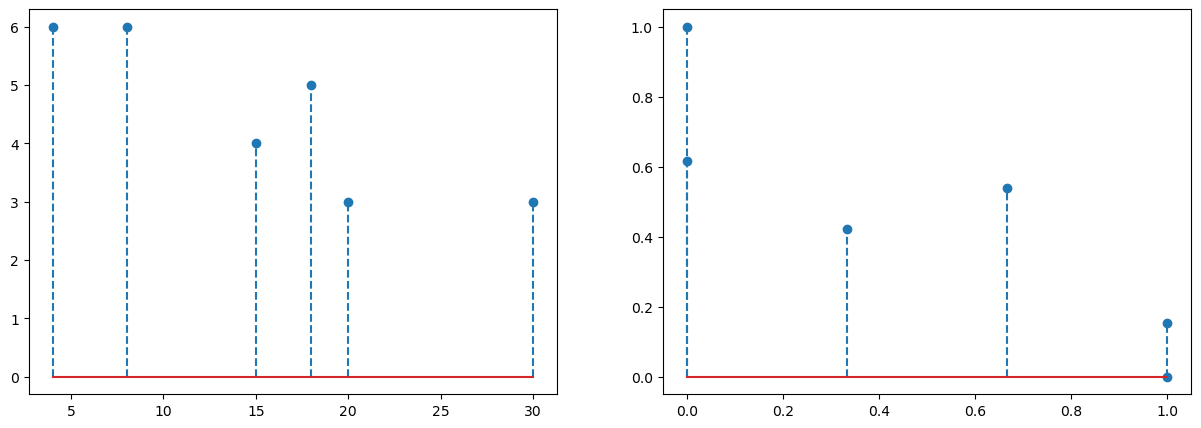

In [24]:
figure,ax=plt.subplots(nrows=1,ncols=2,figsize=(15,5))

ax[0].stem(xtrain["age"],xtrain["bedrooms"],linefmt="--")
# ax[0].set_xlim(0, 21)
# ax[0].set_ylim(0, 7)

ax[1].stem(xtrain_scaled[0],xtrain_scaled[1],linefmt="--")
# ax[1].set_xlim(0, 21)
# ax[1].set_ylim(0, 7)

#### Max Absolute normalization

In [25]:
from sklearn.preprocessing import MaxAbsScaler
scaler=MaxAbsScaler()
xMaxAbs=scaler.fit_transform(xtrain)

In [26]:
xMaxAbs=pd.DataFrame(xMaxAbs)
xMaxAbs

,0,1
0,0.666667,0.500000
1,0.500000,0.666667
2,0.500000,1.000000
3,0.833333,0.600000
4,1.000000,0.266667
5,1.000000,0.133333


#### Robust scaling

In [27]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
xRobust=scaler.fit_transform(xtrain)

In [28]:
xRobust=pd.DataFrame(xRobust)
xRobust

,0,1
0,-0.2,-0.153846
1,-0.6,0.358974
2,-0.6,1.384615
3,0.2,0.153846
4,0.6,-0.871795
5,0.6,-1.282051


#### comparing MinMax Scaling, max  Absolute normalizatio and Robust scalingn

Text(0.5, 1.0, 'Robust scaling')

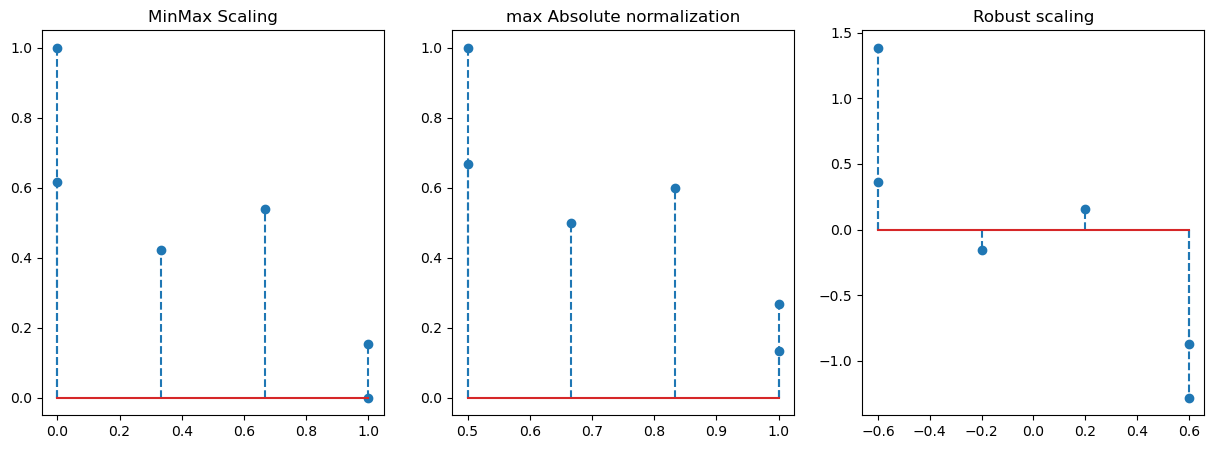

In [29]:
figure,ax=plt.subplots(nrows=1,ncols=3,figsize=(15,5))

ax[0].stem(xtrain_scaled[0],xtrain_scaled[1],linefmt="--")
ax[0].set_title("MinMax Scaling")

ax[1].stem(xMaxAbs[0],xMaxAbs[1],linefmt="--")
ax[1].set_title("max Absolute normalization")

ax[2].stem(xRobust[0],xRobust[1],linefmt="--")
ax[2].set_title("Robust scaling")

<div class="alert alert-warning"><center><h2>Handling Categorical Data</h2></center></div>

<h3 class="alert alert-block alert-success">Ordinal Data</h3>

In [30]:
data=pd.read_csv("titanic.csv")
print(f"shape = {data.shape}")
print(f"size = {data.size}")
data.head(2)

shape = (891, 15)
size = 13365


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [31]:
data.drop(["survived","pclass","age","parch","adult_male","embarked","deck"],axis=1,inplace=True)
print(f"shape = {data.shape}")
print(f"size = {data.size}")
data.head(2)

shape = (891, 8)
size = 7128


,sex,sibsp,fare,class,who,embark_town,alive,alone
0,male,1,7.2500,Third,man,Southampton,no,False
1,female,1,71.2833,First,woman,Cherbourg,yes,False


In [32]:
data.isnull().sum()

sex            0
sibsp          0
fare           0
class          0
who            0
embark_town    2
alive          0
alone          0
dtype: int64

In [33]:
data.dropna(inplace=True)
data.isnull().sum()

sex            0
sibsp          0
fare           0
class          0
who            0
embark_town    0
alive          0
alone          0
dtype: int64

In [34]:
pd.DataFrame(data[data.duplicated()].value_counts())

count
sex    sibsp fare     class  who   embark_town alive alone       
male   0     8.0500   Third  man   Southampton no    True      35
             7.8958   Third  man   Southampton no    True      31
             13.0000  Second man   Southampton no    True      23
             7.7500   Third  man   Queenstown  no    True      13
             10.5000  Second man   Southampton no    True      13
...                                                           ...
female 2     262.3750 First  woman Cherbourg   yes   False      1
       1     113.2750 First  woman Cherbourg   yes   False      1
             78.2667  First  woman Cherbourg   yes   False      1
             77.9583  First  woman Southampton yes   False      1
male   0     7.7958   Third  man   Southampton yes   True       1

[120 rows x 1 columns]

In [35]:
data.nunique()

sex              2
sibsp            7
fare           247
class            3
who              3
embark_town      3
alive            2
alone            2
dtype: int64

In [36]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(data.iloc[:,[3]],data.iloc[:,[-1]],test_size=0.30,random_state=50)
xtrain.head(3)

,class
169,Third
694,First
111,Third


In [37]:
xtrain.value_counts()

class 
Third     336
First     153
Second    133
Name: count, dtype: int64

In [38]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[["Third","Second","First"]])
oe.fit(xtrain)
xtrain_oe=oe.transform(xtrain)
xtest_oe=oe.transform(xtest)
type(xtrain_oe)

numpy.ndarray

In [39]:
xtrain_oe[0:5]

array([[0.],
       [2.],
       [0.],
       [1.],
       [0.]])

<h3 class="alert alert-block alert-success">Label Encoding</h3>

**Label Encoding** _is only used for the **output** column_

In [40]:
ytrain = ytrain.values.ravel()
ytest = ytest.values.ravel()

In [41]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(ytrain)
ytrain_le=le.transform(ytrain)
ytest_le=le.transform(ytest)
type(ytrain_le)

numpy.ndarray

In [42]:
ytrain_le

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,

<h3 class="alert alert-block alert-success">Nominal Data</h3>

In [43]:
data.head(2)

,sex,sibsp,fare,class,who,embark_town,alive,alone
0,male,1,7.2500,Third,man,Southampton,no,False
1,female,1,71.2833,First,woman,Cherbourg,yes,False


In [44]:
data["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [45]:
data["who"].value_counts()

who
man      537
woman    269
child     83
Name: count, dtype: int64

#### OneHot Encoding using pandas

In [46]:
pd.get_dummies(data,columns=["sex","who","embark_town"],drop_first=True)

,sibsp,fare,class,alive,alone,sex_male,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton
0,1,7.2500,Third,no,False,True,True,False,False,True
1,1,71.2833,First,yes,False,False,False,True,False,False
2,0,7.9250,Third,yes,True,False,False,True,False,True
3,1,53.1000,First,yes,False,False,False,True,False,True
4,0,8.0500,Third,no,True,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,13.0000,Second,no,True,True,True,False,False,True
887,0,30.0000,First,yes,True,False,False,True,False,True
888,1,23.4500,Third,no,False,False,False,True,False,True
889,0,30.0000,First,yes,True,True,True,False,False,False


use **drop_first** to remove **multicollinearity**  
**Multicollinearity**: _multicollinearity occurs when two or more independent variables (features) in a regression model are highly correlated with each other_

#### OneHot Encoding using SkLearn

In [47]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop="first",sparse_output=False)
xtrain_ohe = ohe.fit_transform(data.iloc[:,[0,4,5]])
xtrain_ohe

array([[1., 1., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 1.],
       ...,
       [0., 0., 1., 0., 1.],
       [1., 1., 0., 0., 0.],
       [1., 1., 0., 1., 0.]])

In [48]:
np.hstack((data[["sibsp","fare","alone"]].values,xtrain_ohe))

array([[1, 7.25, False, ..., 0.0, 0.0, 1.0],
       [1, 71.2833, False, ..., 1.0, 0.0, 0.0],
       [0, 7.925, True, ..., 1.0, 0.0, 1.0],
       ...,
       [1, 23.45, False, ..., 1.0, 0.0, 1.0],
       [0, 30.0, True, ..., 0.0, 0.0, 0.0],
       [0, 7.75, True, ..., 0.0, 1.0, 0.0]], dtype=object)

<div class="alert alert-warning"><center><h2>Handling Missinig value</h2></center></div>

<h3 class="alert alert-block alert-success">|:----preliminary work----:|</h3>

In [49]:
data=pd.read_csv("food_coded.csv")
print(f"shape = {data.shape}")
print(f"size = {data.size}")
data.head(2)

shape = (125, 61)
size = 7625


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

<h3 class="alert alert-block alert-success">Droping missing columns</h3>

In [51]:
# persentage of the missing values
data.isnull().mean()*100

GPA                  1.6
Gender               0.0
breakfast            0.0
calories_chicken     0.0
calories_day        15.2
                    ... 
type_sports         20.8
veggies_day          0.0
vitamins             0.0
waffle_calories      0.0
weight               1.6
Length: 61, dtype: float64

In [52]:
# separating the columns which have less then 5% of its DATA missing
cols =[x for x in data.columns if data[x].isnull().mean() < 0.05 and data[x].isnull().mean() > 0]
cols

['GPA',
 'calories_scone',
 'comfort_food',
 'comfort_food_reasons',
 'cook',
 'diet_current',
 'drink',
 'eating_changes',
 'father_education',
 'father_profession',
 'fav_cuisine',
 'fav_food',
 'food_childhood',
 'healthy_meal',
 'ideal_diet',
 'income',
 'life_rewarding',
 'marital_status',
 'meals_dinner_friend',
 'mother_education',
 'mother_profession',
 'on_off_campus',
 'persian_food',
 'self_perception_weight',
 'soup',
 'sports',
 'tortilla_calories',
 'weight']

In [53]:
# finding if we drop this rows how much data will remain
len(data[cols].dropna())/len(data)*100

80.80000000000001

In [54]:
new_data = data[cols].dropna()
data.shape , new_data.shape

((125, 61), (101, 28))

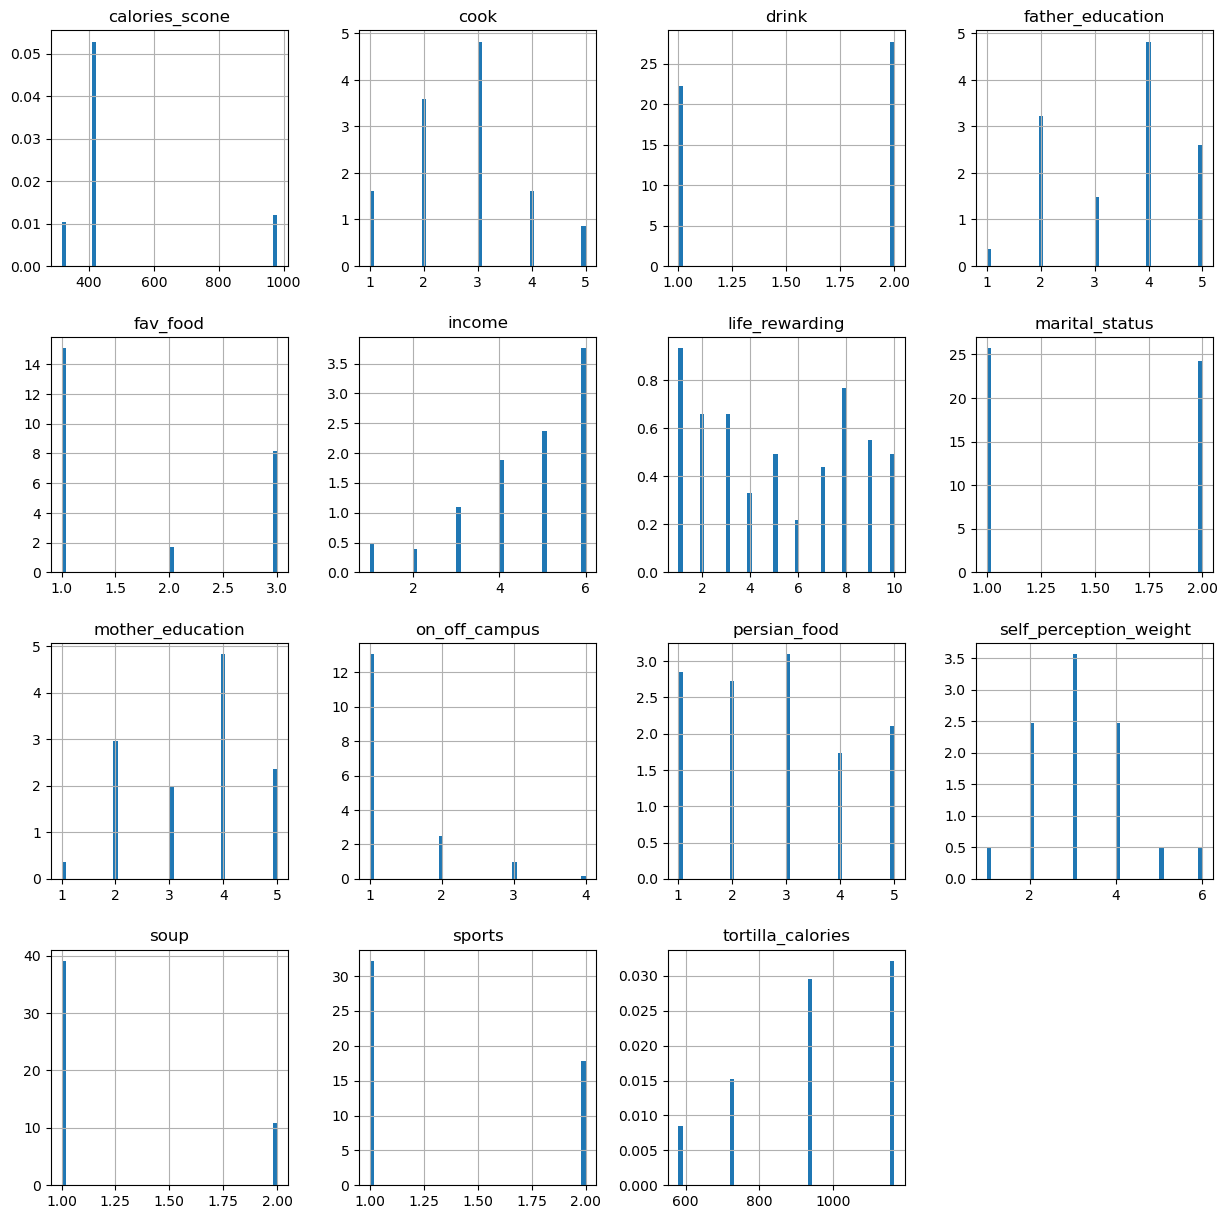

In [55]:
new_data.hist(bins=50, density=True, figsize=(15,15))
plt.show()

<Axes: xlabel='life_rewarding', ylabel='Density'>

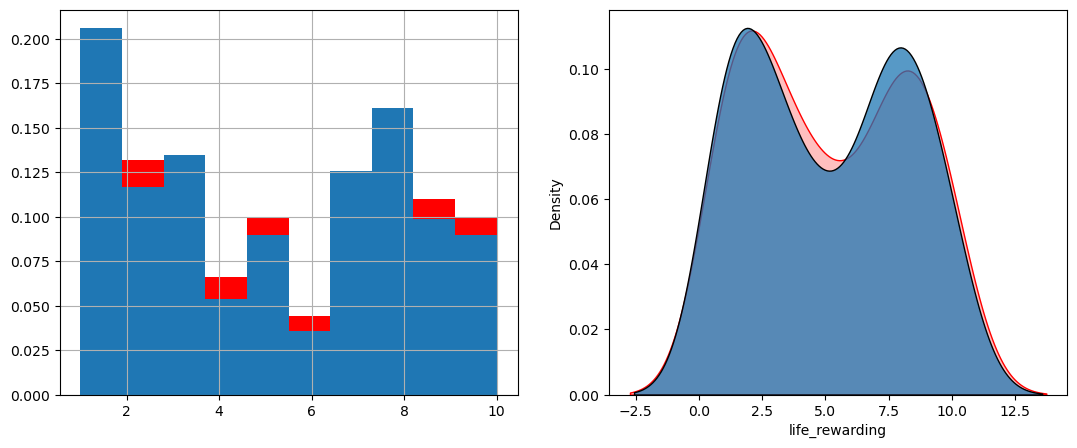

In [56]:
figure,ax = plt.subplots(nrows=1,ncols=2,figsize=(13,5))

# life_rewarding
new_data["life_rewarding"].hist(bins=10,density=True,color="red",ax=ax[0])
data["life_rewarding"].hist(bins=10,density=True,ax=ax[0])

sns.kdeplot(new_data["life_rewarding"],fill=True,color="red",ax=ax[1])
sns.kdeplot(data["life_rewarding"],fill=True,multiple="stack",ax=ax[1])

In [57]:
data[cols].info(),data[cols].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   GPA                     123 non-null    object 
 1   calories_scone          124 non-null    float64
 2   comfort_food            124 non-null    object 
 3   comfort_food_reasons    123 non-null    object 
 4   cook                    122 non-null    float64
 5   diet_current            124 non-null    object 
 6   drink                   123 non-null    float64
 7   eating_changes          122 non-null    object 
 8   father_education        124 non-null    float64
 9   father_profession       122 non-null    object 
 10  fav_cuisine             123 non-null    object 
 11  fav_food                123 non-null    float64
 12  food_childhood          124 non-null    object 
 13  healthy_meal            124 non-null    object 
 14  ideal_diet              124 non-null    ob

(None,
 GPA                        38
 calories_scone              3
 comfort_food              124
 comfort_food_reasons      106
 cook                        5
 diet_current              124
 drink                       2
 eating_changes            121
 father_education            5
 father_profession         114
 fav_cuisine                60
 fav_food                    3
 food_childhood            114
 healthy_meal              124
 ideal_diet                124
 income                      6
 life_rewarding             10
 marital_status              3
 meals_dinner_friend       121
 mother_education            5
 mother_profession         112
 on_off_campus               4
 persian_food                5
 self_perception_weight      6
 soup                        2
 sports                      2
 tortilla_calories           4
 weight                     47
 dtype: int64)

In [58]:
# chack the ratio of the categorical column unique values
temp = pd.concat(
    [
        data["weight"].value_counts()/len(data["weight"]),
        new_data["weight"].value_counts()/len(new_data["weight"])        
    ],
        axis=1)
temp.columns=["original","CAA"]
temp.sample(5)

,original,CAA
weight,,
115,0.008,NaN
112,0.008,NaN
260,0.008,0.009901
155,0.048,0.049505
165,0.040,0.039604


<h3 class="alert alert-block alert-success">Handling <b>UNIVARIAT</b> numerical missing Data</h3>

<h4 class="alert alert-block alert-danger">Using mean/median , By=("pandas")</h4>

In [59]:
temp=[x for x in data.columns if data[x].isnull().sum()>15]
temp

['calories_day', 'comfort_food_reasons_coded', 'cuisine', 'type_sports']

In [60]:
data["cuisine"].head(5)

0    NaN
1    1.0
2    3.0
3    2.0
4    2.0
Name: cuisine, dtype: float64

In [61]:
mean_cuisine=data["cuisine"].fillna(data["cuisine"].mean())
median_cuisine = data["cuisine"].fillna(data["cuisine"].median())
numerical_missing_value_comparison=pd.DataFrame({"original":data["cuisine"],"mean":mean_cuisine,"median":median_cuisine})
numerical_missing_value_comparison

,original,mean,median
0,NaN,1.388889,1.0
1,1.0,1.000000,1.0
2,3.0,3.000000,3.0
3,2.0,2.000000,2.0
4,2.0,2.000000,2.0
...,...,...,...
120,1.0,1.000000,1.0
121,NaN,1.388889,1.0
122,NaN,1.388889,1.0
123,1.0,1.000000,1.0


<Axes: >

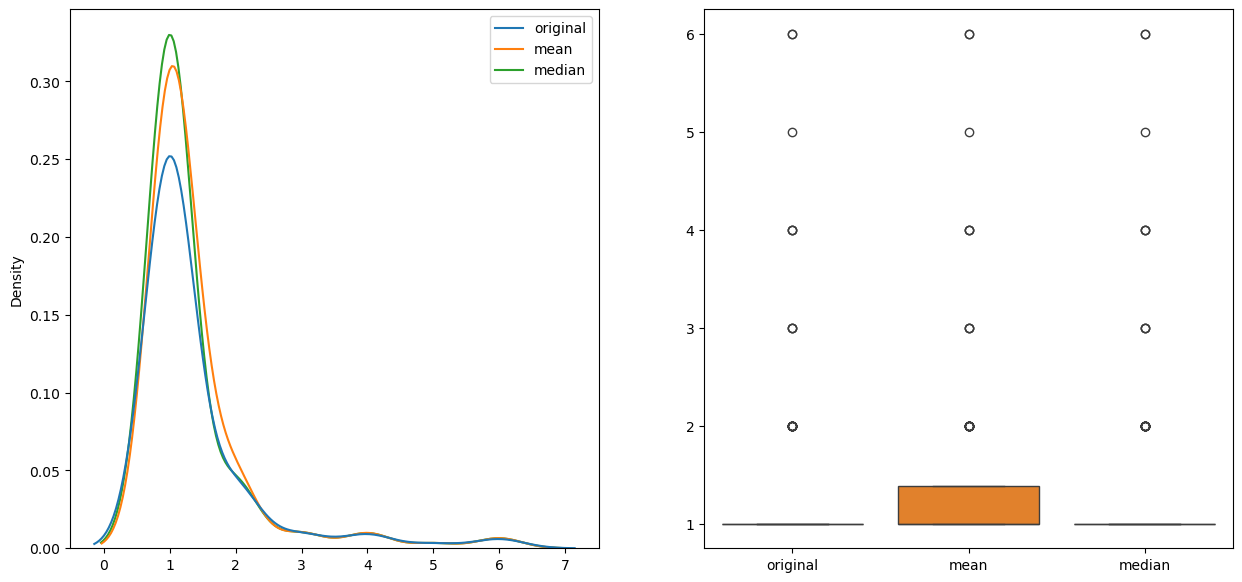

In [62]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,7))
sns.kdeplot(numerical_missing_value_comparison,ax=ax1)
sns.boxplot(numerical_missing_value_comparison,ax=ax2)

<h4 class="alert alert-block alert-danger">Using mean/median , By=("Sklearn")</h4>

In [63]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy="median")
si.fit(pd.DataFrame(data.cuisine))
si.statistics_

array([1.])

In [64]:
si_median_cuisine = si.transform(pd.DataFrame(data.cuisine))
si_median_cuisine[:5]

array([[1.],
       [1.],
       [3.],
       [2.],
       [2.]])

In [65]:
check = pd.DataFrame({"cuisine":data["cuisine"],"si_median_cuisine":si_median_cuisine.ravel()})
check.head(3)

,cuisine,si_median_cuisine
0,NaN,1.0
1,1.0,1.0
2,3.0,3.0


<Axes: >

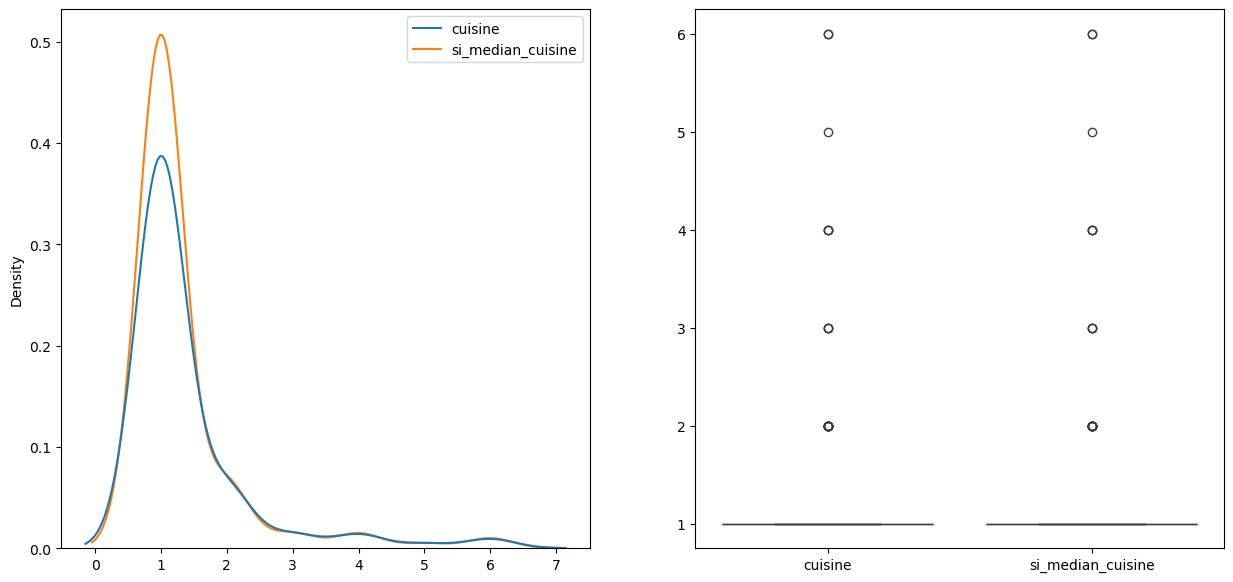

In [66]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,7))
sns.kdeplot(check,ax=ax1)
sns.boxplot(check,ax=ax2)

<h4 class="alert alert-block alert-danger">Arbitarry value , By=("Sklearn")</h4>

In [67]:
from sklearn.impute import SimpleImputer
si_arbitarry = SimpleImputer(strategy = "constant",fill_value=-1)
si_arbitarry.fit(pd.DataFrame(data.cuisine))
si.statistics_

array([1.])

In [68]:
si_arbitarry_cuisine = si_arbitarry.transform(pd.DataFrame(data.cuisine))
si_arbitarry_cuisine[:5]

array([[-1.],
       [ 1.],
       [ 3.],
       [ 2.],
       [ 2.]])

In [69]:
check_arbitarry = pd.DataFrame({"cuisine":data["cuisine"],"si_arbitarry_cuisine":si_arbitarry_cuisine.ravel()})
check_arbitarry.head(3)

,cuisine,si_arbitarry_cuisine
0,NaN,-1.0
1,1.0,1.0
2,3.0,3.0


<Axes: >

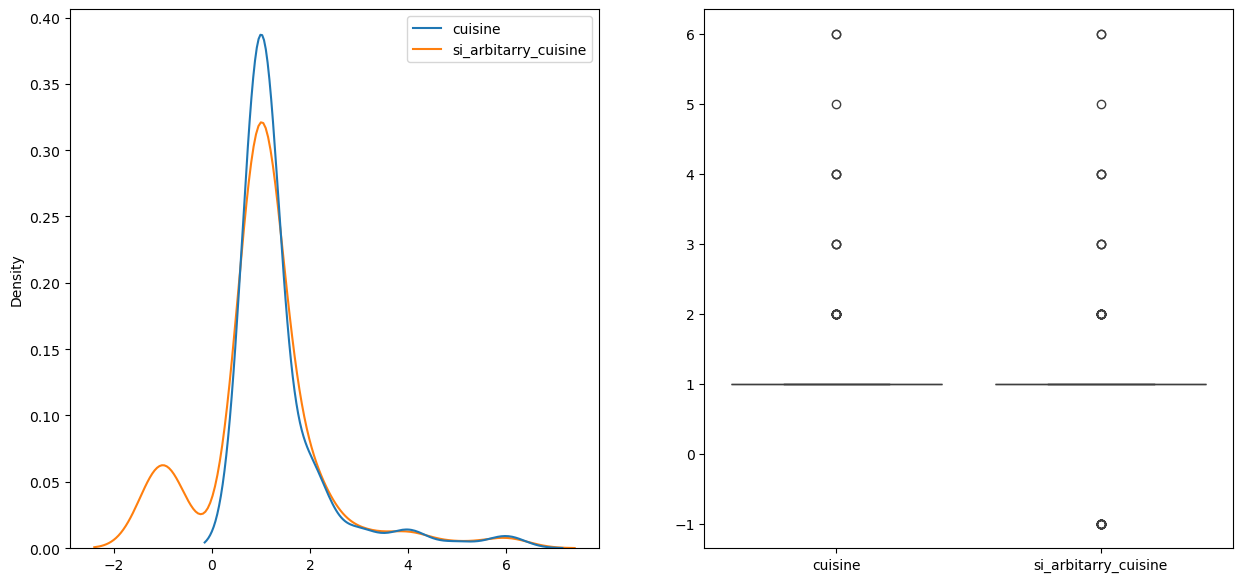

In [70]:
fig,(ax1,ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,7))
sns.kdeplot(check_arbitarry,ax=ax1)
sns.boxplot(check_arbitarry,ax=ax2)

<h3 class="alert alert-block alert-success">Handling <b>UNIVARIAT</b> catagorical missing Data</h3>

<h4 class="alert alert-block alert-danger">Most Frequent</h4>

In [71]:
data1 = data[["fav_cuisine","father_profession","mother_profession","income"]]
data1.head(2)

,fav_cuisine,father_profession,mother_profession,income
0,Arabic cuisine,profesor,unemployed,5.0
1,Italian,Self employed,Nurse RN,4.0


In [72]:
data1.isnull().mean()*100

fav_cuisine          1.6
father_profession    2.4
mother_profession    1.6
income               0.8
dtype: float64

<Axes: xlabel='fav_cuisine'>

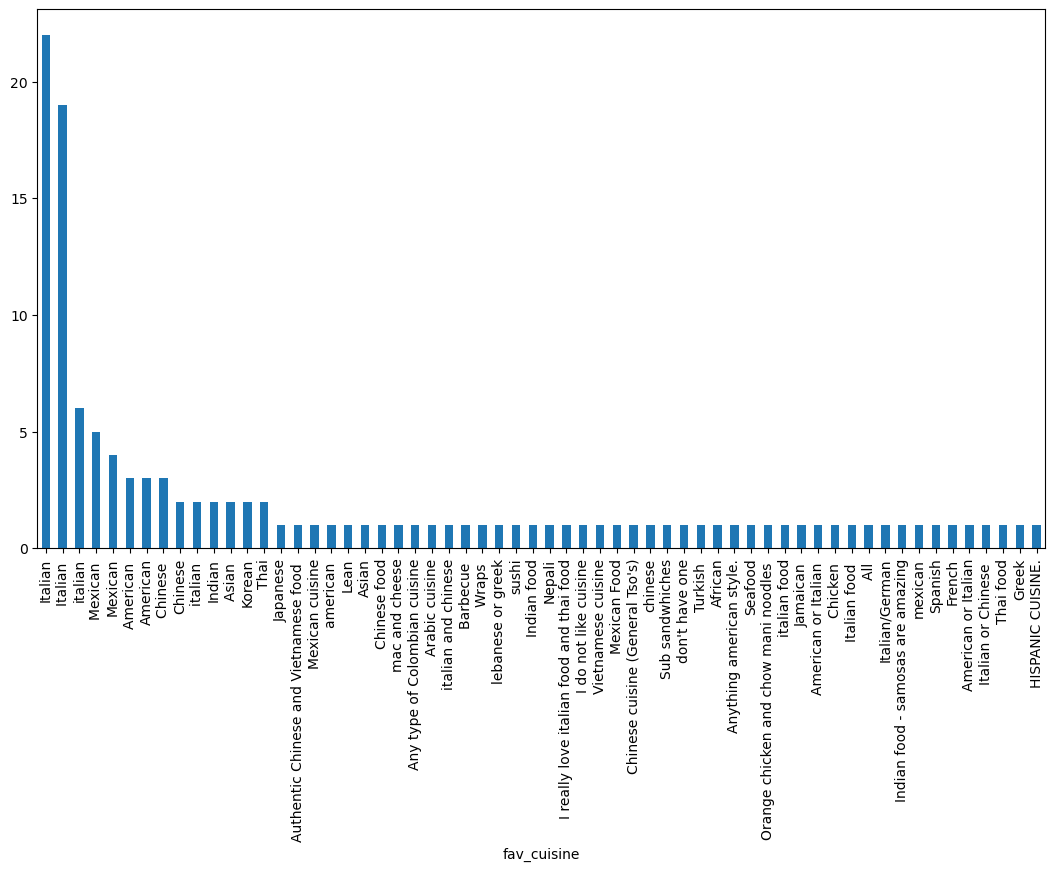

In [73]:
# number and count of unique values
plt.figure(figsize=(13,7))
data1["fav_cuisine"].value_counts().plot(kind="bar")

In [74]:
data1["fav_cuisine"].mode()

0    Italian
Name: fav_cuisine, dtype: object

In [75]:
x=data1.iloc[:,:-1]
x.head(2)

,fav_cuisine,father_profession,mother_profession
0,Arabic cuisine,profesor,unemployed
1,Italian,Self employed,Nurse RN


In [76]:
from sklearn.impute import SimpleImputer
si_frequent = SimpleImputer(strategy="most_frequent")
si_frequent.fit(x)
si_frequent.statistics_

array(['Italian', 'Business Owner', 'Secretary'], dtype=object)

In [77]:
si_frequent_values = si_frequent.transform(x)
si_frequent_values=pd.DataFrame(si_frequent_values)
si_frequent_values

,0,1,2
0,Arabic cuisine,profesor,unemployed
1,Italian,Self employed,Nurse RN
2,italian,owns business,owns business
3,Turkish,Mechanic,Special Education Teacher
4,Italian,IT,Substance Abuse Conselor
...,...,...,...
120,Italian,Accountant,Radiological Technician
121,Mexican Food,Doctor,Public Health Advisor
122,Korean,CEO of company,Real Estate manageer
123,Italian,Store manager at Giant Eagle,Receptionist for a medical supply company


In [78]:
si_frequent_values["income"]=data1["income"]
si_frequent_values.head(2)

,0,1,2,income
0,Arabic cuisine,profesor,unemployed,5.0
1,Italian,Self employed,Nurse RN,4.0


Text(0.5, 1.0, 'after')

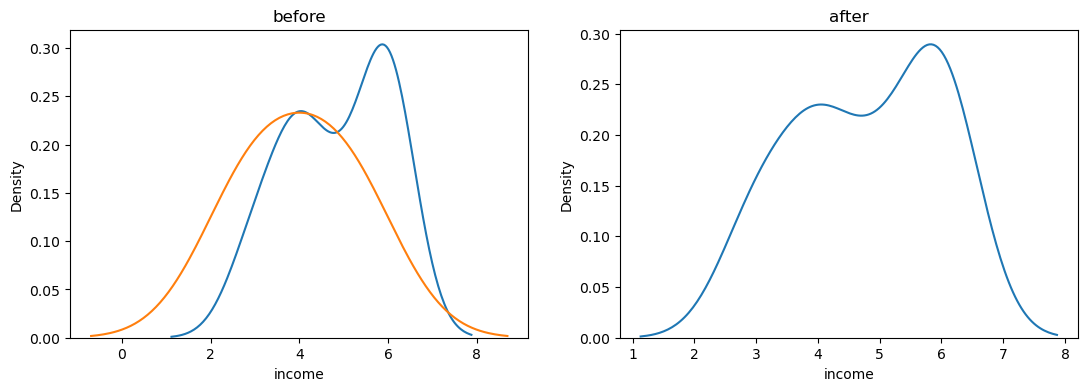

In [79]:
figure,(ax1,ax2) = plt.subplots(ncols=2,figsize=(13,4))

sns.kdeplot(data1[data1["fav_cuisine"] == "Italian"]["income"],ax=ax1)
sns.kdeplot(data1[data1["fav_cuisine"].isnull()]["income"],ax=ax1)
ax1.set_title("before")

sns.kdeplot(si_frequent_values[si_frequent_values[0] == "Italian"]["income"],ax=ax2)
sns.kdeplot(si_frequent_values[si_frequent_values[0].isnull()]["income"],ax=ax2)
ax2.set_title("after")

<h3 class="alert alert-block alert-success">Handling <b>UNIVARIAT</b> catagorical and numerical missing Data</h3>

<h4 class="alert alert-block alert-danger">New "Missing" category</h4>

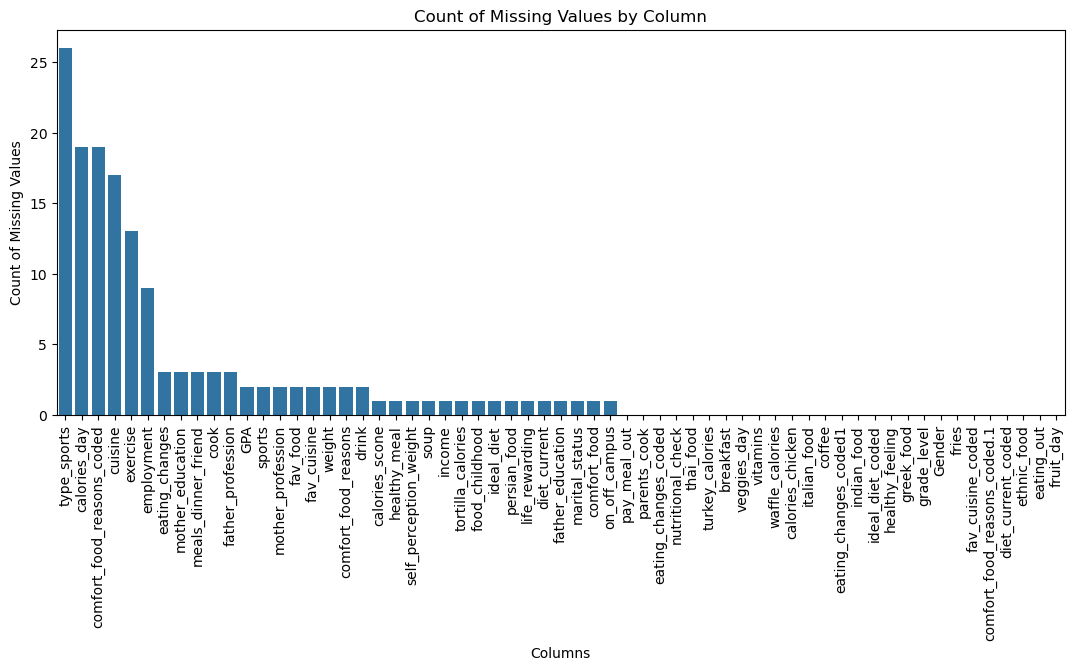

In [80]:
# Assuming 'data' is your pandas DataFrame
# First, let's create a Series of the missing values count
missing_values_count = data.isnull().sum()

# Then, create the sorted order
# We will use the index of the sorted Series for the order
missing_values_count_sorted = missing_values_count.sort_values(ascending=False)

# Now, create the bar plot
plt.figure(figsize=(13, 5))

# Use the sorted Series directly for x and y
ax = sns.barplot(x=missing_values_count_sorted.index, y=missing_values_count_sorted.values)

# Set the x-axis tick labels rotation
ax.tick_params(axis="x", rotation=90)

# Set a title and labels for clarity
plt.title('Count of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')

# Display the plot
plt.show()

In [81]:
data[missing_values_count_sorted.index].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   type_sports                   99 non-null     object 
 1   calories_day                  106 non-null    float64
 2   comfort_food_reasons_coded    106 non-null    float64
 3   cuisine                       108 non-null    float64
 4   exercise                      112 non-null    float64
 5   employment                    116 non-null    float64
 6   eating_changes                122 non-null    object 
 7   mother_education              122 non-null    float64
 8   meals_dinner_friend           122 non-null    object 
 9   cook                          122 non-null    float64
 10  father_profession             122 non-null    object 
 11  GPA                           123 non-null    object 
 12  sports                        123 non-null    float64
 13  mothe

**without additional columns**

In [82]:
check_indicator_data = data[["calories_day","comfort_food_reasons_coded","cuisine","exercise","employment","income"]]
check_indicator_data.head(4)

,calories_day,comfort_food_reasons_coded,cuisine,exercise,employment,income
0,NaN,9.0,NaN,1.0,3.0,5.0
1,3.0,1.0,1.0,1.0,2.0,4.0
2,4.0,1.0,3.0,2.0,3.0,6.0
3,3.0,2.0,2.0,3.0,3.0,6.0


In [83]:
check_indicator_data_pure = check_indicator_data.dropna()

In [84]:
x=check_indicator_data_pure.iloc[:,:-1]
y=check_indicator_data_pure.iloc[:,[-1]]

In [85]:
from sklearn.linear_model import LinearRegression
lr1=LinearRegression()
lr1.fit(x,y)

LinearRegression()

In [86]:
ypred = lr1.predict(x)
ypred[:2]

array([[4.83148729],
       [5.80032278]])

In [87]:
from sklearn.metrics import r2_score; 
r2_score(y, ypred)

0.12460627788875789

**with additional indicator columns**

In [88]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(add_indicator=True)
xnew = si.fit_transform(x)
xnew[:2]

array([[3., 1., 1., 1., 2.],
       [4., 1., 3., 2., 3.]])

In [89]:
from sklearn.linear_model import LinearRegression
lr2=LinearRegression()
lr2.fit(xnew,y)

LinearRegression()

In [90]:
ynewpred = lr2.predict(xnew)
ynewpred[:2]

array([[4.83148729],
       [5.80032278]])

In [91]:
from sklearn.metrics import r2_score; 
r2_score(y, ynewpred)

0.12460627788875789

<h3 class="alert alert-block alert-success">Handling <b>BIVARIAT</b> numerical missing Data</h3>

<h4 class="alert alert-block alert-danger">KNN imputer</h4>

In [92]:
check_indicator_data.head(2)

,calories_day,comfort_food_reasons_coded,cuisine,exercise,employment,income
0,NaN,9.0,NaN,1.0,3.0,5.0
1,3.0,1.0,1.0,1.0,2.0,4.0


In [93]:
x=check_indicator_data_pure.iloc[:,:-1]
y=check_indicator_data_pure.iloc[:,[-1]]

In [94]:
from sklearn.impute import KNNImputer
KnnI=KNNImputer(n_neighbors=5)
x_knnI = KnnI.fit_transform(x)
x_knnI[:5]

array([[3., 1., 1., 1., 2.],
       [4., 1., 3., 2., 3.],
       [3., 2., 2., 3., 3.],
       [2., 1., 2., 1., 2.],
       [3., 1., 1., 1., 3.]])

In [95]:
from sklearn.linear_model import LinearRegression
lr2=LinearRegression()
lr2.fit(x_knnI,y)

LinearRegression()

In [96]:
ypred_knnI = lr2.predict(x_knnI)
ypred_knnI[:2]

array([[4.83148729],
       [5.80032278]])

In [97]:
from sklearn.metrics import r2_score; 
r2_score(y, ypred_knnI)

0.12460627788875789

<h4 class="alert alert-block alert-danger">MICE (Multivariate Imputation by Chained Equations)</h4>

_It works by iteratively imputing missing values in each variable using a model based on the other variables in the dataset. This process is repeated until the imputations converge, producing multiple imputed datasets_

**Steps**  
|step no.|working|
|--------|-------|
|1|fill the NAN values by the mean value corresponding to their column and save it in a veriable|
|2|Remove the value of first column mean to NAN again as it was|
|3|treat the first column as dependent variables output and rest columns as Independent veriables|
|4|use Independent veriables and first column as training data set (do not use rows with NaN value)|
|5|train any ML model by the data set|
|6|predict the value if the NAN by the model|
|7|Repeat the steps from 2 to 6 moving left to right in the column|
|8|when the model completes predicting all the NAN value in every row subtract it from the first mean veriable |
|9|if the ans of the subraction is a zero matrix then prediction is right|
|10|if it is not, then consider the prediction matices as a base matrix and repeat from step 2|

In [98]:
miceData = data[["calories_day","comfort_food_reasons_coded","cuisine"]]
miceData.head(3)

,calories_day,comfort_food_reasons_coded,cuisine
0,NaN,9.0,NaN
1,3.0,1.0,1.0
2,4.0,1.0,3.0


In [99]:
miceData.isnull().mean()*100

calories_day                  15.2
comfort_food_reasons_coded    15.2
cuisine                       13.6
dtype: float64

In [100]:
def prediction_maker(baseData,miceData):
    columns = baseData.columns
    baseData_copy = baseData.copy()
    for i in columns:
        baseData_copy[f"{i}"] = miceData[f"{i}"]

        # seperating the x and y veriables
        xtest = baseData_copy[baseData_copy[f"{i}"].isnull()==True][columns[columns != i]]
        xtrain = baseData_copy[baseData_copy[f"{i}"].isnull()==False][columns[columns != i]]
        ytrain = baseData_copy[baseData_copy[f"{i}"].isnull()==False][f"{i}"]

        Null_indexes = baseData_copy[baseData_copy[f"{i}"].isnull()==True].index.tolist()

        # model making and traning
        lr = LinearRegression()
        lr.fit(xtrain,ytrain)

        # print("-------------------model traning...")

        # predection
        new_column = lr.predict(xtest)
        baseData_copy.loc[Null_indexes,i]=new_column

        
    return baseData_copy

In [101]:
def MICE_handler(miceData,iter):
    from sklearn.linear_model import LinearRegression

    from sklearn.impute import SimpleImputer
    si = SimpleImputer()
    baseData=si.fit_transform(miceData)
    baseData = pd.DataFrame(baseData,columns=miceData.columns)
    
    for i in range(iter):
        print(f"{"-"*20}iteration{i}{"-"*20}")
        newDF = prediction_maker(baseData,miceData)
        diff_pd = (baseData - newDF)
        if np.all(diff_pd.values == 0):
            print("forced step value found....")
            return newDF
        else:
            baseData = newDF
    print(newDF)
    return newDF

In [102]:
temp = MICE_handler(miceData,100)

--------------------iteration0--------------------
--------------------iteration1--------------------
--------------------iteration2--------------------
--------------------iteration3--------------------
--------------------iteration4--------------------
--------------------iteration5--------------------
--------------------iteration6--------------------
--------------------iteration7--------------------
--------------------iteration8--------------------
--------------------iteration9--------------------
--------------------iteration10--------------------
--------------------iteration11--------------------
--------------------iteration12--------------------
--------------------iteration13--------------------
--------------------iteration14--------------------
--------------------iteration15--------------------
--------------------iteration16--------------------
--------------------iteration17--------------------
forced step value found....


In [103]:
temp

,calories_day,comfort_food_reasons_coded,cuisine
0,3.074783,9.000000,1.624483
1,3.000000,1.000000,1.000000
2,4.000000,1.000000,3.000000
3,3.000000,2.000000,2.000000
4,2.000000,1.000000,2.000000
...,...,...,...
120,4.000000,2.710821,1.000000
121,2.000000,2.636191,1.333508
122,3.028429,2.708396,1.388796
123,4.000000,2.710821,1.000000


<div class="alert alert-warning"><center><h2>Outlier detection</h2></center></div>

<h3 class="alert alert-block alert-success">|:----preliminary work----:|</h3>

In [104]:
data=pd.read_csv("food_coded.csv",usecols=["cook","income","life_rewarding"])
data.dropna(inplace=True)
data.head(4)

,cook,income,life_rewarding
0,2.0,5.0,1.0
1,3.0,4.0,1.0
2,1.0,6.0,7.0
3,2.0,6.0,2.0


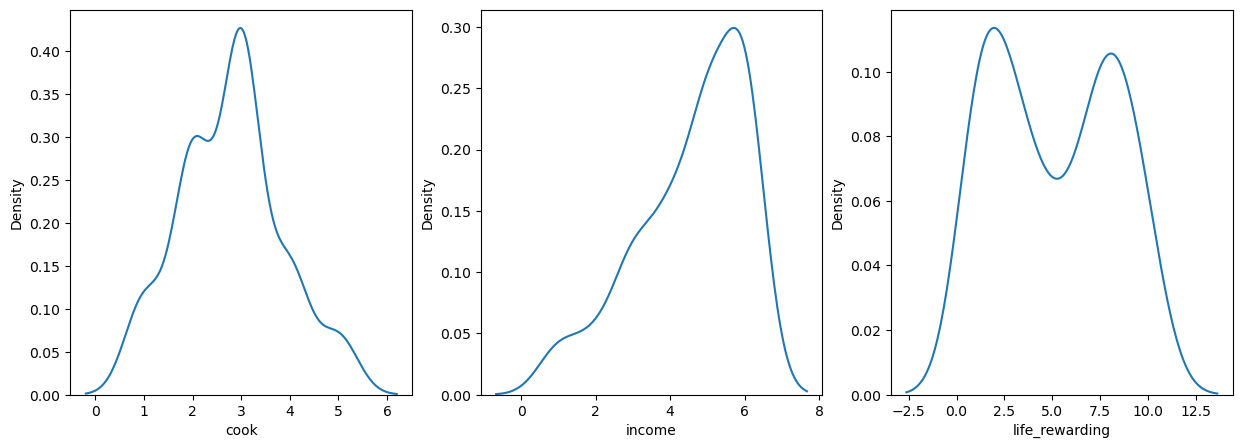

In [105]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(15,5))
for i in range(3):
    col=data.columns[i]
    sns.kdeplot(data[col],ax=ax[i])

_here you can see that_  
**cook column** is normally distributed  
**income column** has skewed distribution  
**life rewarding column** has random  

<h3 class="alert alert-block alert-success">Z-score method</h3>

1. Z-score utilize statistical properties to identify outliers. The Z-score measures how many standard deviations an observation from the mean.  
1. Use in case of **normally distribution** 

In [106]:
print(f"mean of the cook column {data["cook"].mean()}")
print(f"std of the cook column {data["cook"].std()}")
print(f"min of the cook column {data["cook"].min()}")
print(f"max of the cook column {data["cook"].max()}")

mean of the cook column 2.783333333333333
std of the cook column 1.038610362259995
min of the cook column 1.0
max of the cook column 5.0


In [107]:
# finding boundry values of the Z-score
print(f"highest allowed {data["cook"].mean()+3*data["cook"].std()}")
print(f"lowest allowed {data["cook"].mean()-3*data["cook"].std()}")

highest allowed 5.899164420113318
lowest allowed -0.3324977534466518


In [108]:
# finding outliers
data[(data["cook"]>4) | (data["cook"]<1)]

,cook,income,life_rewarding
12,5.0,5.0,9.0
20,5.0,6.0,2.0
22,5.0,6.0,5.0
32,5.0,5.0,8.0
39,5.0,6.0,5.0
50,5.0,1.0,8.0
79,5.0,6.0,3.0
108,5.0,6.0,5.0


use **np.where(_condition_ , _true_statement_ , _false_statement_)** to resolve it

<h3 class="alert alert-block alert-success">IQR method</h3>

1. The Interquartile Range (IQR) method is a statistical technique used to identify outliers in a dataset
2. use in case of **skewed distribution**

![](https://www.scribbr.com/wp-content/uploads/2022/01/interquartile-range.png)

**Folmula**  
|Fence|formula|
|-----|-------|
|Lower fence |$$Q1-1.5*IQR$$|
|upper fence |$$Q1+1.5*IQR$$|

<Axes: xlabel='income'>

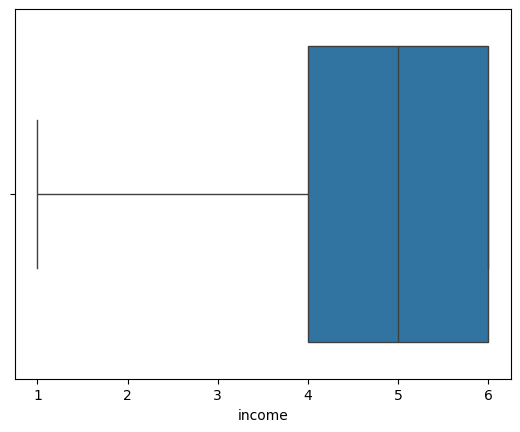

In [109]:
sns.boxplot(data["income"],orient="h")

In [110]:
# finding IQR
Q1=data["income"].quantile(0.25)
Q3=data["income"].quantile(0.75)
print(f"the q1 is {Q1} and q3 is {Q3}")

the q1 is 4.0 and q3 is 6.0


In [111]:
IQR = Q3-Q1
print(f"the IQR is {IQR}")

the IQR is 2.0


In [112]:
# finding boundry values of the Z-score
upperLimit=Q3+1.5*IQR
lowerlimit=Q1-1.5*IQR

print(f"highest allowed {upperLimit}")
print(f"lowest allowed {lowerlimit}")

highest allowed 9.0
lowest allowed 1.0


<h3 class="alert alert-block alert-success">percentile method</h3>

_The percentile method detects outliers by identifying data points that fall outside a specified range defined by percentiles_

<Axes: xlabel='life_rewarding'>

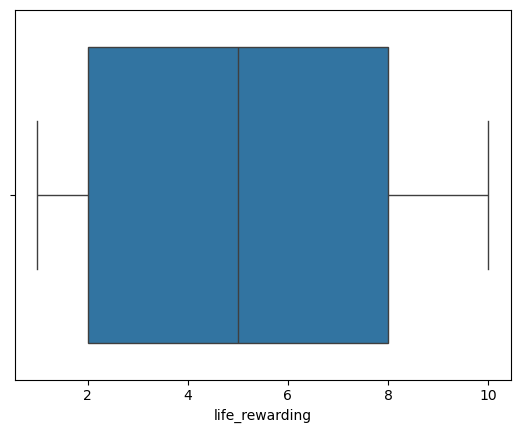

In [113]:
sns.boxplot(data["life_rewarding"],orient="h")

In [114]:
# finding boundry values of the Z-score
upperLimit=data["life_rewarding"].quantile(0.99)
lowerlimit=data["life_rewarding"].quantile(0.1)

print(f"highest allowed {upperLimit}")
print(f"lowest allowed {lowerlimit}")

highest allowed 10.0
lowest allowed 1.0


<div class="alert alert-info">                  
<center><h1><b>Feature Construction</b></h1></center>
</div>  

<div class="alert alert-info">                  
<center><h1><b>Feature Selection</b></h1></center>
</div>  

<div class="alert alert-info">                  
<center><h1><b>Feature Extraction</b></h1></center>
</div>  

<div class="alert alert-warning"><center><h2>PCA (Principle Component Analysis)</h2></center></div>

**Principal Component Analysis (PCA)** _is a statistical method used to reduce the dimensionality of complex, multi-variable datasets by transforming the original correlated variables into a smaller set of uncorrelated new variables called principal components (PCs)_  

1. It chooses which columns are important by their spreads
2. Mostly used for categorical columns in data

In [115]:
data = pd.read_csv("sonar.all-data.csv")
column_name = [f"input_{x}" for x in range(len(data.columns)-1)]
column_name.append("output")
data.columns=[column_name]
data.head(2)

,input_0,input_1,input_2,input_3,input_4,input_5,input_6,input_7,input_8,input_9,...,input_51,input_52,input_53,input_54,input_55,input_56,input_57,input_58,input_59,output
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R


In [116]:
data.isnull().sum()

input_0     0
input_1     0
input_2     0
input_3     0
input_4     0
           ..
input_56    0
input_57    0
input_58    0
input_59    0
output      0
Length: 61, dtype: int64

In [117]:
data.shape

(207, 61)

In [118]:
data.index

RangeIndex(start=0, stop=207, step=1)

<Axes: ylabel='Density'>

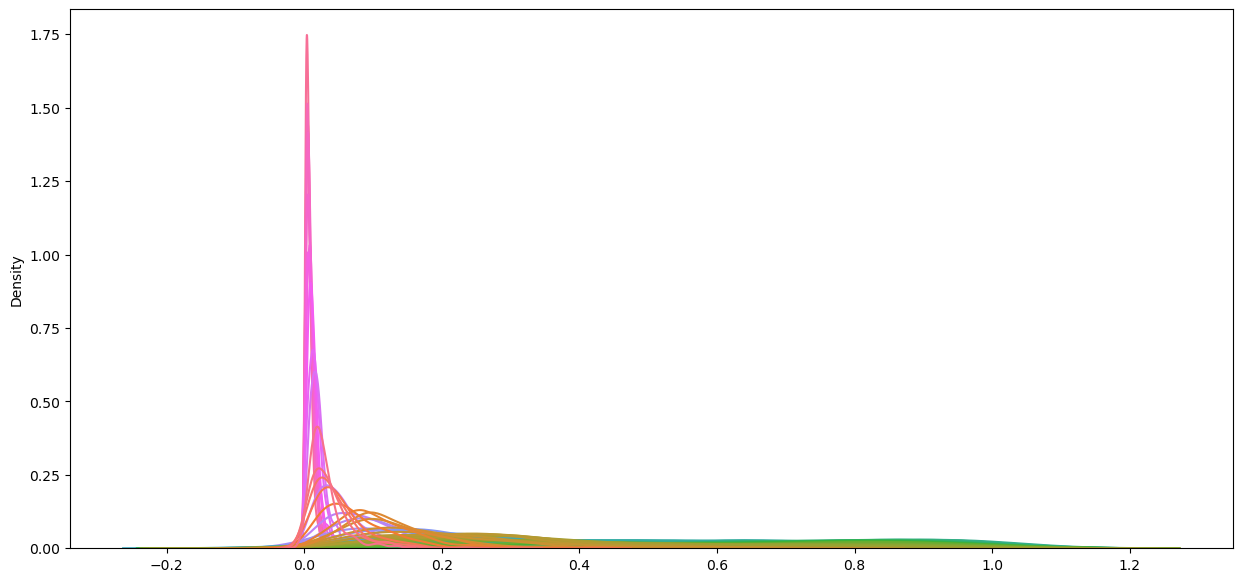

In [119]:
plt.figure(figsize=(15,7))
sns.kdeplot(data.iloc[:,:-1],legend=False)

In [120]:
x=data.iloc[:,:-1]
y=data.iloc[:,[-1]]

In [121]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.25,random_state=50)
print(f"xtrain = {xtrain.shape}")
print(f"xtest = {xtest.shape}")
print(f"ytrain = {ytrain.shape}")
print(f"ytest = {ytest.shape}")

xtrain = (155, 60)
xtest = (52, 60)
ytrain = (155, 1)
ytest = (52, 1)


In [122]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
xtrain_scaled = Scaler.fit_transform(xtrain)
xtest_scaled = Scaler.transform(xtest)
xtrain_scaled

array([[-0.29554854, -0.80317631, -0.73673377, ..., -0.57509288,
        -0.25627148, -0.49847348],
       [-0.44633325, -0.61211469, -0.34005665, ...,  0.67741324,
         0.55373493,  0.04976197],
       [ 1.21637379,  0.24623675,  0.16995679, ...,  0.54728273,
         0.52196997,  0.65471143],
       ...,
       [-0.36890327, -0.76040132, -0.55687396, ...,  0.43341854,
         1.30021143,  1.27856556],
       [ 0.45429973,  2.13118793,  0.21923346, ...,  2.35284351,
         0.29961527,  0.37114137],
       [-0.40558063, -0.63492802, -0.2094735 , ...,  0.40088591,
         0.04549562, -0.55518749]])

Text(0.5, 1.0, 'after')

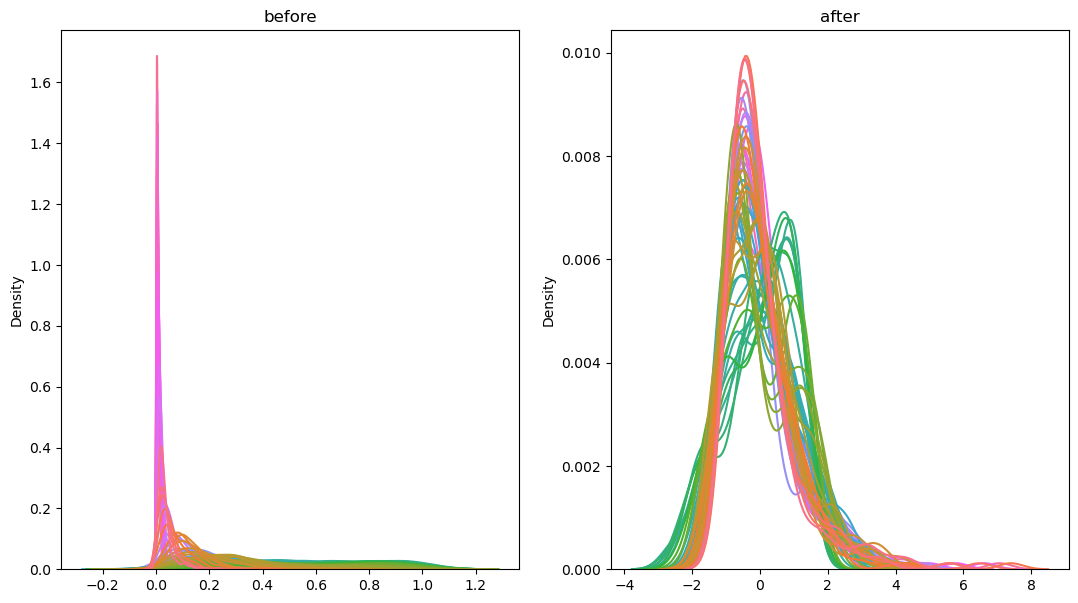

In [123]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(13,7))

sns.kdeplot(xtrain,legend=False,ax=ax1)
ax1.set_title("before")

sns.kdeplot(xtrain_scaled,legend=False,ax=ax2)
ax2.set_title("after")

In [124]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(xtrain_scaled,ytrain)

C:\Users\updes\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [125]:
import time
start = time.time()
ypred = knn.predict(xtest_scaled)
print(time.time()-start)

0.14354562759399414


In [126]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.8269230769230769

In [127]:
ypred

array(['M', 'M', 'R', 'R', 'M', 'R', 'M', 'R', 'R', 'R', 'M', 'M', 'R',
       'M', 'M', 'M', 'M', 'R', 'M', 'M', 'M', 'M', 'R', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'R', 'M', 'R', 'R', 'M', 'M', 'R', 'R', 'R',
       'M', 'M', 'M', 'R', 'M', 'R', 'M', 'M', 'M', 'R', 'M', 'R', 'M'],
      dtype=object)

In [128]:
#PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=50)
pca.fit(xtrain_scaled)

PCA(n_components=50)

In [129]:
xtrain_scaled_pca = pca.transform(xtrain_scaled)
xtest_scaled_pca = pca.transform(xtest_scaled)
xtrain_scaled_pca.shape

(155, 50)

In [130]:
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.metrics import accuracy_score

knn=KNeighborsClassifier()
knn.fit(xtrain_scaled_pca,ytrain)

start = time.time()
ypred = knn.predict(xtest_scaled_pca)
print(f"time taken ={time.time()-start}s")

print(f"accuracy_score = {accuracy_score(ytest,ypred)}")

time taken =0.004000663757324219s
accuracy_score = 0.8269230769230769


C:\Users\updes\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [131]:
import warnings
warnings.filterwarnings('ignore')

accuracy_score_list=[]
time_taken_list=[]

for i in range(1,60,3):
    pca=PCA(n_components=i)
    pca.fit(xtrain_scaled)
    xtrain_scaled_pca = pca.transform(xtrain_scaled)
    xtest_scaled_pca = pca.transform(xtest_scaled)
    
    knn=KNeighborsClassifier()
    knn.fit(xtrain_scaled_pca,ytrain)

    start = time.time()
    ypred = knn.predict(xtest_scaled_pca)
    time_taken = time.time()-start

    accuracy = accuracy_score(ytest,ypred)
    
    accuracy_score_list.append(accuracy)
    time_taken_list.append(time_taken)
    
    print(f"{i}:components | accuracy => {accuracy} | time => {time_taken}s")

1:components | accuracy => 0.5769230769230769 | time => 0.005001068115234375s
4:components | accuracy => 0.7884615384615384 | time => 0.0040013790130615234s
7:components | accuracy => 0.8269230769230769 | time => 0.004001617431640625s
10:components | accuracy => 0.9038461538461539 | time => 0.0040018558502197266s
13:components | accuracy => 0.8846153846153846 | time => 0.00400090217590332s
16:components | accuracy => 0.8846153846153846 | time => 0.003000974655151367s
19:components | accuracy => 0.8653846153846154 | time => 0.0030014514923095703s
22:components | accuracy => 0.9230769230769231 | time => 0.003002166748046875s
25:components | accuracy => 0.8846153846153846 | time => 0.002000570297241211s
28:components | accuracy => 0.8653846153846154 | time => 0.0020012855529785156s
31:components | accuracy => 0.8653846153846154 | time => 0.0029985904693603516s
34:components | accuracy => 0.8653846153846154 | time => 0.003002166748046875s
37:components | accuracy => 0.8846153846153846 | ti

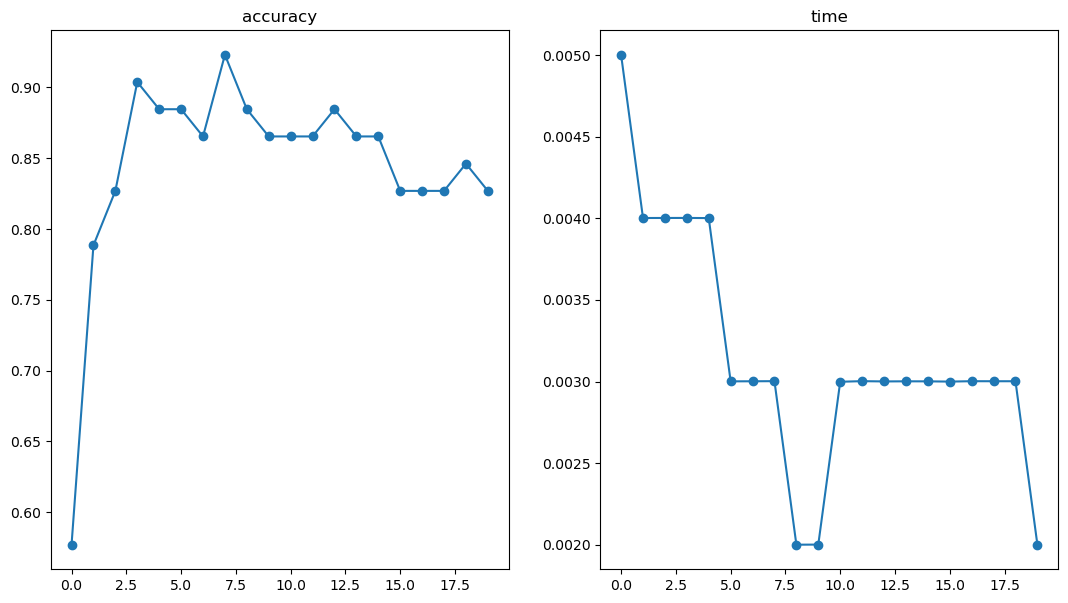

In [132]:
plot_accuracy_time = pd.DataFrame({"accuracy":accuracy_score_list,"time_taken":time_taken_list})

fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(13,7))

ax1.plot(plot_accuracy_time.index,plot_accuracy_time["accuracy"],marker="o")
ax1.set_title("accuracy")

ax2.set_title("time")
ax2.plot(plot_accuracy_time.index,plot_accuracy_time["time_taken"],marker="o")